# iTRAILS results

Loads the outputs produced by the workflow (`gwf run` in the repository root) and
gives a first look at each analysis: the fitted model parameters, the Viterbi
segmentation of the alignment into gene-tree states, and the posterior state
probabilities along the alignment.

The notebook is executed by the workflow itself once all upstream targets are
done, so it simply discovers whatever analyses exist under `steps/itrails/`
(each analysis has one subfolder per step: `split/`, `optimize/`, `viterbi/`,
`posterior/`, `concat/`).

In [1]:
import vscodenb
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from IPython.display import display, Markdown

In [2]:
steps_dir = Path('..') / 'steps' / 'itrails'
analyses = sorted(p for p in steps_dir.glob('*') if p.is_dir()) if steps_dir.exists() else []
if not analyses:
    print('No iTRAILS results found yet - run the workflow first (see the README).')
[p.name for p in analyses]

['alternative', 'example']

## Fitted model parameters

The best parameter set found by `itrails-optimize` for each analysis
(times in generations, `r` per site per generation):

In [3]:
for analysis in analyses:
    name = analysis.name
    best_model = analysis / 'optimize' / f'{name}.best_model.yaml'
    if not best_model.exists():
        # fit: window mode has one best_model per window instead
        window_models = sorted((analysis / 'optimize').glob('*.best_model.yaml'))
        display(Markdown(f"### {name}\n{len(window_models)} per-window model fits "
                         f"in `{analysis / 'optimize'}`"))
        continue
    with open(best_model) as f:
        best = yaml.safe_load(f)
    display(Markdown(f"### {name}\n"
                     f"log likelihood: **{best['results']['log_likelihood']}** "
                     f"(iteration {best['results']['iteration']})"))
    display(pd.Series(best['optimized_parameters'], name='estimate', dtype=float).to_frame())

### alternative
2 per-window model fits in `../steps/itrails/alternative/optimize`

### example
log likelihood: **-1697168.3387257133** (iteration 14)

,estimate
N_AB,5.074074e+04
N_ABC,5.592593e+04
r,9.802469e-09
t_1,2.544444e+05
t_2,3.974074e+04
t_upper,6.273300e+05


## Viterbi decoding

How much of the alignment is assigned to each hidden state (a gene-tree topology
combined with coalescence-time intervals), and the state sequence along the
genome (windowed analyses, using `concat/{name}.viterbi.csv`) or along the
largest alignment block (unwindowed analyses):

In [5]:
analysis = analyses[1]

name = analysis.name
windowed = (analysis / 'concat' / f'{name}.viterbi.csv').exists()
if windowed:
    # concatenated per-window decode; block_start + block-local position
    # places each segment on the binning-reference genome
    vit = pd.read_csv(analysis / 'concat' / f'{name}.viterbi.csv')
    vit['genome_start'] = vit['block_start'] + vit['position_start']
    vit['genome_end'] = vit['block_start'] + vit['position_end']
    # under fit: genome every window has the same state legend
    states_file = sorted((analysis / 'viterbi').glob('*.hidden_states.csv'))[0]
else:
    vit = pd.read_csv(analysis / 'viterbi' / f'{name}.viterbi.csv')
    states_file = analysis / 'viterbi' / f'{name}.hidden_states.csv'
states = pd.read_csv(states_file)
labels = states.set_index('state_idx')['shorthand_name']
vit['length'] = vit['position_end'] - vit['position_start'] + 1

vit['most_likely_state'] = vit.most_likely_state.astype(int)
vit['most_likely_state'] = pd.Categorical(vit.most_likely_state, categories=states.index.values, ordered=True)

bp_per_state = (vit.groupby('most_likely_state', observed=False)['length'].sum()
                    .rename(index=labels)#.sort_values()
                    )

In [6]:
states['a'], states['b'], states['c']= zip(*states.shorthand_name.apply(eval))
states.head()


,state_idx,topology,interval_1st_coalescent,interval_2nd_coalescent,shorthand_name,a,b,c
0,0,"({sp1,sp2},sp3)",315157.64-357526.97,315157.64-357526.97,"(0, 0, 0)",0,0,0
1,1,"({sp1,sp2},sp3)",315157.64-357526.97,357526.97-429957.80,"(0, 0, 1)",0,0,1
2,2,"({sp1,sp2},sp3)",315157.64-357526.97,429957.80-inf,"(0, 0, 2)",0,0,2
3,3,"({sp1,sp2},sp3)",357526.97-429957.80,315157.64-357526.97,"(0, 1, 0)",0,1,0
4,4,"({sp1,sp2},sp3)",357526.97-429957.80,357526.97-429957.80,"(0, 1, 1)",0,1,1


In [7]:
vit.head()

,window,chrom,block_start,src_block,Block_idx,position_start,position_end,most_likely_state,genome_start,genome_end,length
0,w0000,hg38.chr1,0,0,0,0,10922,7,0,10922,10923
1,w0000,hg38.chr1,0,0,0,10923,17091,19,10923,17091,6169
2,w0000,hg38.chr1,0,0,0,17092,18289,23,17092,18289,1198
3,w0000,hg38.chr1,0,0,0,18290,49999,8,18290,49999,31710
4,w0000,hg38.chr1,50000,1,1,0,15396,10,50000,65396,15397


In [8]:
bp_per_state

most_likely_state
(0, 0, 0)     56413
(0, 0, 1)    119189
(0, 0, 2)    259670
(0, 1, 0)         0
(0, 1, 1)     56149
(0, 1, 2)     56562
(0, 2, 0)     11761
(0, 2, 1)     41856
(0, 2, 2)    272912
(1, 0, 0)         0
(1, 0, 1)     15397
(1, 0, 2)     50974
(1, 1, 1)         0
(1, 1, 2)         0
(1, 2, 2)      1378
(2, 0, 0)         0
(2, 0, 1)         0
(2, 0, 2)      4359
(2, 1, 1)         0
(2, 1, 2)     26088
(2, 2, 2)      3006
(3, 0, 0)         0
(3, 0, 1)         0
(3, 0, 2)     11331
(3, 1, 1)         0
(3, 1, 2)     12463
(3, 2, 2)       492
Name: length, dtype: int64

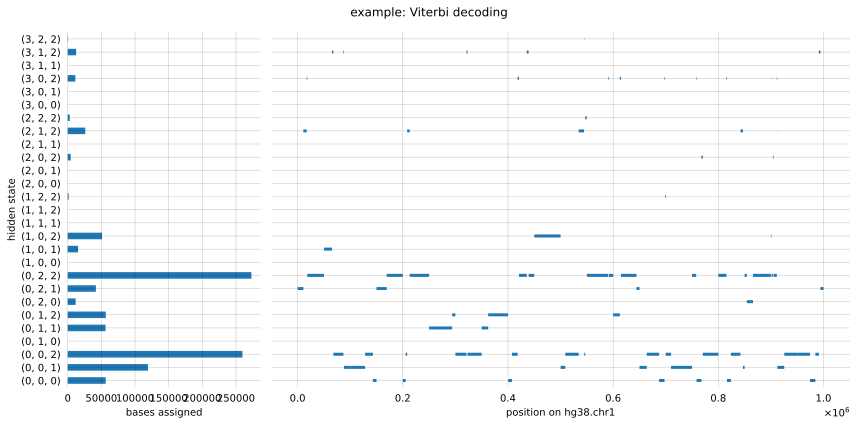

In [9]:

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True, 
                             width_ratios=(1, 3))

bp_per_state.plot.barh(ax=axes[0], color='C0')
axes[0].set_xlabel('bases assigned')
axes[0].set_ylabel('hidden state')

if windowed:
    for seg in vit.itertuples():
        axes[1].hlines(seg.most_likely_state, seg.genome_start, seg.genome_end,
                        lw=3, color='C0')
    axes[1].set_xlabel(f"position on {vit['chrom'].iloc[0]}")
else:
    largest_block = vit.groupby('Block_idx')['length'].sum().idxmax()
    block = vit[vit['Block_idx'] == largest_block]
    for seg in block.itertuples():
        axes[1].hlines(seg.most_likely_state, seg.position_start, seg.position_end,
                        lw=3, color='C0')
    axes[1].set_xlabel(f'position in block {largest_block}')
axes[1].set_ylabel('state index')

fig.suptitle(f'{name}: Viterbi decoding')
fig.tight_layout()


## Posterior decoding

Posterior probability of every hidden state along the genome (windowed analyses,
using `concat/{name}.posterior.csv`) or along the largest alignment block
(unwindowed analyses). Positions are subsampled for plotting when the sequence
is long:

In [ ]:
analysis = analyses[1]
name = analysis.name
windowed = (analysis / 'concat' / f'{name}.posterior.csv').exists()
if windowed:
    post = pd.read_csv(analysis / 'concat' / f'{name}.posterior.csv')
    prob_cols = [c for c in post.columns if c.startswith('prob_state_')]
    post['genome_pos'] = post['block_start'] + post['position_idx']
    post = post.sort_values('genome_pos')
    probs = post[prob_cols].to_numpy().T
    xlabel = f"position on {post['chrom'].iloc[0]}"
else:
    post = pd.read_csv(analysis / 'posterior' / f'{name}.posterior.csv')
    prob_cols = [c for c in post.columns if c.startswith('prob_state_')]
    block_col = post.columns[0]
    largest_block = post[block_col].value_counts().idxmax()
    probs = post[post[block_col] == largest_block][prob_cols].to_numpy().T
    xlabel = f'position in block {largest_block}'

In [99]:

def max_prob_segments(probs, collapse=False):

    if collapse:
        df = pd.DataFrame(probs)
        df['a'], df['b'], df['c']= zip(*states.shorthand_name.apply(eval))
        # df = df.loc[df.a > 1]
        df.set_index(['a', 'b', 'c'], inplace=True)
        df = df.groupby('a').agg('sum').T
        probs = df.to_numpy().T

    df = pd.DataFrame(dict(
        pos=np.arange(probs.shape[1]),
        prob=np.max(probs, axis=0),
        most_likely_state=np.argmax(probs, axis=0),
    ))
    df['_run'] = (df.most_likely_state != df.most_likely_state.shift()).cumsum()

    max_prob_segments = (
        df
        .groupby(['most_likely_state', '_run'])
#        .agg({'pos': ['min', 'max'], 'prob': 'mean'})
        .agg(genome_start=pd.NamedAgg(column="pos", aggfunc="min"),
             genome_end=pd.NamedAgg(column="pos", aggfunc="max"),
             mean_prob=pd.NamedAgg(column="prob", aggfunc="mean")
        )
        .reset_index()
        .drop(columns=['_run'])
    )
    # max_prob_segments.columns = max_prob_segments.columns.to_flat_index().map(lambda x: '_'.join(x))
    return max_prob_segments.sort_values('genome_start')#.rename(columns={'pos_min': 'start', 'pos_max': 'end'})

In [100]:
max_prob_segments(probs, collapse=False)

,most_likely_state,genome_start,genome_end,mean_prob
271,11,0,322,0.212630
314,13,323,611,0.178241
374,19,612,742,0.165325
315,13,743,755,0.150726
272,11,756,1015,0.177547
...,...,...,...,...
399,22,992493,993891,0.314063
427,23,993892,994156,0.407241
400,22,994157,994381,0.251929
270,10,994382,996371,0.195224


In [101]:
post_decoding = max_prob_segments(probs, collapse=True)
post_decoding

,most_likely_state,genome_start,genome_end,mean_prob
62,1,0,631,0.460841
85,2,632,731,0.368332
63,1,732,788,0.349207
0,0,789,10240,0.727682
86,2,10241,12359,0.547829
...,...,...,...,...
59,0,951679,980337,0.942180
124,2,980338,982746,0.522549
60,0,982747,991176,0.872005
170,3,991177,994312,0.760779


In [120]:
total_bp = post_decoding.groupby('most_likely_state').apply(lambda x: (x.genome_end - x.genome_start).sum()).to_frame('total_bp').reset_index()
total_bp['most_likely_state'] = total_bp.most_likely_state.astype('category')

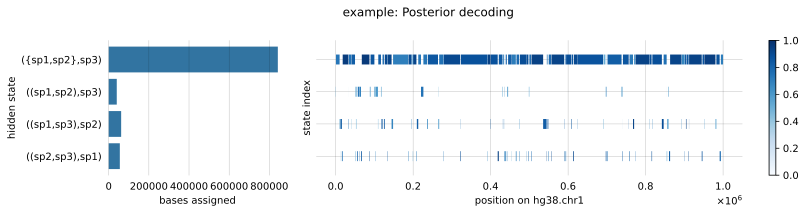

In [142]:

fig, axes = plt.subplots(1, 2, figsize=(12, 3), sharey=True, 
                             width_ratios=(1, 3))

sns.barplot(total_bp, x='total_bp', y='most_likely_state', ax=axes[0])

axes[0].set_xlabel('bases assigned')
axes[0].set_ylabel('hidden state')
axes[0].set_yticks([0, 1, 2, 3])
axes[0].set_yticklabels(['({sp1,sp2},sp3)', '((sp1,sp2),sp3)', '((sp1,sp3),sp2)', '((sp2,sp3),sp1)'])

cmap = plt.get_cmap('Blues')
# if windowed:
for seg in post_decoding.itertuples():
    axes[1].hlines(seg.most_likely_state, seg.genome_start, seg.genome_end,
                    lw=10, color=cmap(seg.mean_prob))
axes[1].set_xlabel(f"position on {vit['chrom'].iloc[0]}")
# else:
#     largest_block = vit.groupby('Block_idx')['length'].sum().idxmax()
#     block = vit[vit['Block_idx'] == largest_block]
#     for seg in block.itertuples():
#         axes[1].hlines(seg.most_likely_state, seg.position_start, seg.position_end,
#                         lw=3, color='C0')
#     axes[1].set_xlabel(f'position in block {largest_block}')
axes[1].set_ylabel('state index')

norm = plt.Normalize(0, 1)
sm = plt.cm.ScalarMappable(cmap="RdBu", norm=norm)
sm.set_array([])

# Remove the legend and add a colorbar
#axes[1].get_legend().remove()
#axes[1].figure.colorbar(sm)

import matplotlib
fig.colorbar(matplotlib.colorizer.ColorizingArtist(matplotlib.colorizer.Colorizer(norm=norm, cmap=cmap)), ax=axes[1])

fig.suptitle(f'{name}: Posterior decoding')
fig.tight_layout()

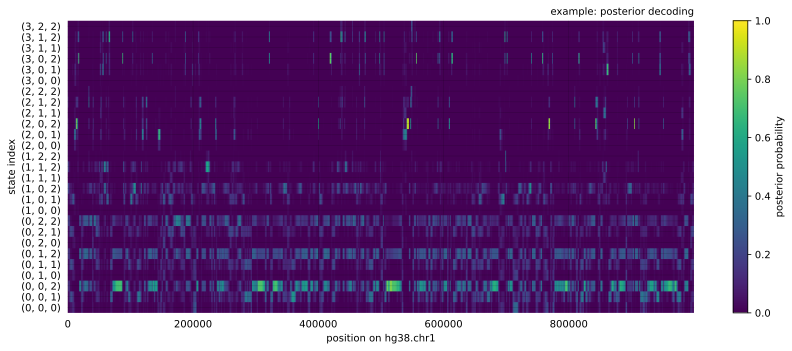

In [ ]:

step = 1 #max(1, probs.shape[1] // 2000)
plt.figure(figsize=(12, 5))
plt.imshow(probs[:, ::step], aspect='auto', origin='lower',
            cmap='viridis', vmin=0, vmax=1, 
            interpolation='nearest')
plt.colorbar(label='posterior probability')
plt.xlabel(xlabel + (f' (every {step} bp)' if step > 1 else ''))
plt.yticks(states.state_idx, states.shorthand_name)
plt.ylabel('state index')
plt.title(f'{name}: posterior decoding')
plt.tight_layout()

In [30]:
df = pd.DataFrame(probs)
df['a'], df['b'], df['c']= zip(*states.shorthand_name.apply(eval))
# df = df.loc[df.a > 1]
df.set_index(['a', 'b', 'c'], inplace=True)
df = df.groupby('a').agg('sum').T
probs = df.to_numpy().T

<Axes: >

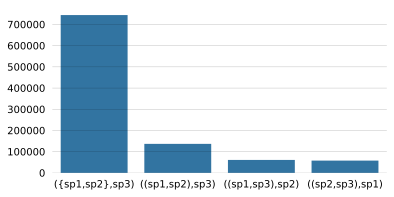

In [31]:
fig, ax = plt.subplots(figsize=(6, 3))
sns.barplot(x=['({sp1,sp2},sp3)', '((sp1,sp2),sp3)', '((sp1,sp3),sp2)', '((sp2,sp3),sp1)'], y=np.sum(probs, axis=1), ax=ax)

Text(1.0, 1.0, 'example: posterior decoding')

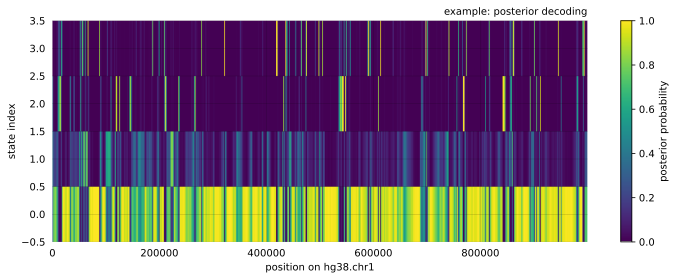

In [32]:
step = 1 #max(1, probs.shape[1] // 2000)
plt.figure(figsize=(12, 4))
plt.imshow(probs[:, ::step], aspect='auto', origin='lower',
            cmap='viridis', vmin=0, vmax=1, 
            interpolation='nearest')
plt.colorbar(label='posterior probability')
plt.xlabel(xlabel + (f' (every {step} bp)' if step > 1 else ''))
plt.ylabel('state index')
plt.title(f'{name}: posterior decoding')

Text(1.0, 1.0, 'example: posterior decoding')

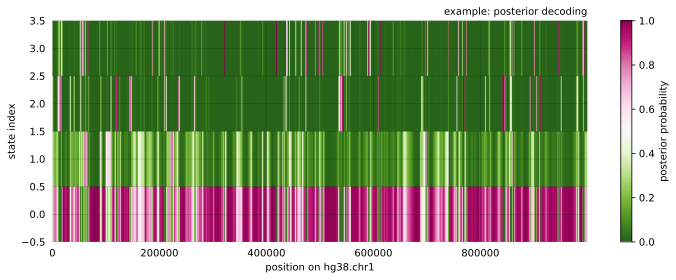

In [160]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors

norm = colors.TwoSlopeNorm(vmin=0, vcenter=0.5, vmax=1)


step = 1 #max(1, probs.shape[1] // 2000)
plt.figure(figsize=(12, 4))
plt.imshow(probs[:, ::step], aspect='auto', origin='lower',
            cmap='PiYG_r', norm=norm,
            interpolation='nearest')
plt.colorbar(label='posterior probability')
plt.xlabel(xlabel + (f' (every {step} bp)' if step > 1 else ''))
plt.ylabel('state index')
plt.title(f'{name}: posterior decoding')

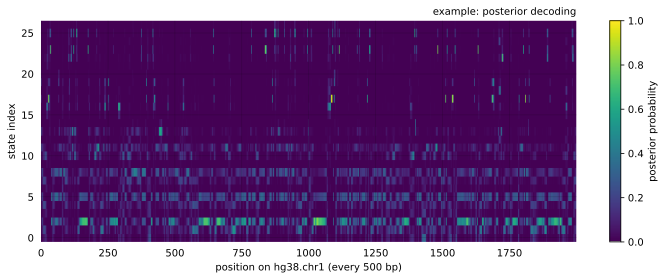

In [19]:
for analysis in analyses:
    name = analysis.name
    windowed = (analysis / 'concat' / f'{name}.posterior.csv').exists()
    if windowed:
        post = pd.read_csv(analysis / 'concat' / f'{name}.posterior.csv')
        prob_cols = [c for c in post.columns if c.startswith('prob_state_')]
        post['genome_pos'] = post['block_start'] + post['position_idx']
        post = post.sort_values('genome_pos')
        probs = post[prob_cols].to_numpy().T
        xlabel = f"position on {post['chrom'].iloc[0]}"
    else:
        post = pd.read_csv(analysis / 'posterior' / f'{name}.posterior.csv')
        prob_cols = [c for c in post.columns if c.startswith('prob_state_')]
        block_col = post.columns[0]
        largest_block = post[block_col].value_counts().idxmax()
        probs = post[post[block_col] == largest_block][prob_cols].to_numpy().T
        xlabel = f'position in block {largest_block}'

    step = max(1, probs.shape[1] // 2000)
    plt.figure(figsize=(12, 4))
    plt.imshow(probs[:, ::step], aspect='auto', origin='lower',
               cmap='viridis', vmin=0, vmax=1, interpolation='nearest')
    plt.colorbar(label='posterior probability')
    plt.xlabel(xlabel + (f' (every {step} bp)' if step > 1 else ''))
    plt.ylabel('state index')
    plt.title(f'{name}: posterior decoding')
    plt.show()